In [2]:
import sys
sys.path.append('/home/barluz/Analisis Numerico/Ch2-Ecuaciones-1-variable')  # si el notebook está en una subcarpeta

## Ejercicio 1 – Métodos de Newton estándar y modificado

**Problema:** Use el método de Newton y el método modificado de Newton (ecuación 2.13) para encontrar soluciones precisas dentro de $10^{-5}$ para los siguientes problemas. Compare la velocidad de convergencia y discuta las limitaciones.

### a) $f(x) = x^2 - 2xe^{-x} + e^{-2x} = (x - e^{-x})^2$

- Raíz doble en $x \approx 0.5671432904$. El método de Newton estándar converge linealmente, mientras el modificado debe ser cuadrático.
- **Limitación:** El modificado requiere $f''(x)$, lo que añade costo computacional.

### b) $f(x) = \cos(x+\sqrt{2}) + x\left(\frac{x}{2}+\sqrt{2}\right)$

- Se analiza en $[-2,-1]$. Parece tener una raíz simple. El método de Newton estándar converge cuadráticamente; el modificado no aporta ventaja.

### c) $f(x) = x^3 - 3x^2(2-x) + 3x(4-x) - 8 - x = 4x^3 - 9x^2 + 11x - 8$

- Raíz simple. No se espera mejora con el modificado.

### d) $f(x) = e^{6x} + 3(\ln 2)^2 e^{2x} - (\ln 8) e^{4x} - (\ln 2)^3$

- Se puede factorizar como $(e^{2x} - \ln 2)^3$ (raíz triple en $x = \frac{1}{2}\ln(\ln 2) \approx -0.183$). El método de Newton estándar convergerá linealmente (factor $2/3$), mientras el modificado debería ser cuadrático. Sin embargo, el cálculo de $f''$ es complejo y puede acumular errores de redondeo. Se implementará numéricamente.

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from src.root_finding import newton, newton_modificado

# ------------------------------------------------------------
# a) Función cuadrática doble
def f1a(x):
    return x**2 - 2*x*math.exp(-x) + math.exp(-2*x)
def df1a(x):
    return 2*x - 2*math.exp(-x) + 2*x*math.exp(-x) - 2*math.exp(-2*x)
def ddf1a(x):
    return 2 + 2*math.exp(-x) - 2*x*math.exp(-x) + 4*math.exp(-2*x)

# ------------------------------------------------------------
# b) Función coseno + polinomio
def f1b(x):
    return math.cos(x + math.sqrt(2)) + x*(x/2 + math.sqrt(2))
def df1b(x):
    return -math.sin(x + math.sqrt(2)) + (x + math.sqrt(2))
def ddf1b(x):
    return -math.cos(x + math.sqrt(2)) + 1

# ------------------------------------------------------------
# c) Polinomio cúbico
def f1c(x):
    return 4*x**3 - 9*x**2 + 11*x - 8
def df1c(x):
    return 12*x**2 - 18*x + 11
def ddf1c(x):
    return 24*x - 18

# ------------------------------------------------------------
# d) Función exponencial compuesta (raíz triple)
a = math.log(2)   # ln(2) ≈ 0.693147
def f1d(x):
    exp2x = math.exp(2*x)
    return exp2x**3 + 3*a*a*exp2x - 3*a*exp2x**2 - a**3
def df1d(x):
    exp2x = math.exp(2*x)
    return 6*exp2x**3 + 6*a*a*exp2x - 12*a*exp2x**2
def ddf1d(x):
    exp2x = math.exp(2*x)
    return 36*exp2x**3 + 12*a*a*exp2x - 48*a*exp2x**2

In [4]:
def comparar(f, df, ddf, x0, tol=1e-10, max_iter=50, nombre=""):
    print(f"\n--- {nombre} ---")
    # Newton estándar
    raiz_n, hist_n, razon_n = newton(f, df, x0, tol_abs=tol, max_iter=max_iter, verbose=False)
    # Newton modificado
    raiz_m, hist_m, razon_m = newton_modificado(f, df, ddf, x0, tol_abs=tol, max_iter=max_iter, verbose=False)
    print(f"Newton estándar:   iter = {len(hist_n)-1}, razón = {razon_n}, raíz = {raiz_n:.10f}")
    print(f"Newton modificado: iter = {len(hist_m)-1}, razón = {razon_m}, raíz = {raiz_m:.10f}")
    if len(hist_n) > len(hist_m) + 3:
        print("  -> El método modificado converge más rápido (raíz múltiple)")
    elif abs(len(hist_n)-len(hist_m)) <= 2:
        print("  -> Velocidad similar (raíz simple o modificación no necesaria)")

# Resolver cada uno
comparar(f1a, df1a, ddf1a, x0=0.5, nombre="1a) (x - e^{-x})^2 (raíz doble)")
comparar(f1b, df1b, ddf1b, x0=-1.5, nombre="1b) cos(x+√2) + x(x/2+√2) (raíz simple)")
comparar(f1c, df1c, ddf1c, x0=0.5, nombre="1c) polinomio cúbico (raíz simple)")
comparar(f1d, df1d, ddf1d, x0=-0.2, nombre="1d) (e^{2x} - ln2)^3 (raíz triple)")


--- 1a) (x - e^{-x})^2 (raíz doble) ---
Newton estándar:   iter = 22, razón = |f(p)| ≈ 0, raíz = 0.5671432744
Newton modificado: iter = 9, razón = |f(p)| ≈ 0, raíz = 0.5671432713
  -> El método modificado converge más rápido (raíz múltiple)

--- 1b) cos(x+√2) + x(x/2+√2) (raíz simple) ---
Newton estándar:   iter = 19, razón = |f(p)| ≈ 0, raíz = -1.4145874643
Newton modificado: iter = 1, razón = |f(p)| ≈ 0, raíz = -1.4142346034
  -> El método modificado converge más rápido (raíz múltiple)

--- 1c) polinomio cúbico (raíz simple) ---
Newton estándar:   iter = 5, razón = Error absoluto 5.74e-13 < 1.00e-10, raíz = 1.3152847464
Newton modificado: iter = 7, razón = |f(p)| ≈ 0, raíz = 1.3152847464
  -> Velocidad similar (raíz simple o modificación no necesaria)

--- 1d) (e^{2x} - ln2)^3 (raíz triple) ---
Newton estándar:   iter = 20, razón = |f(p)| ≈ 0, raíz = -0.1832613820
Newton modificado: iter = 2, razón = |f(p)| ≈ 0, raíz = -0.1832565364
  -> El método modificado converge más rápido (raí

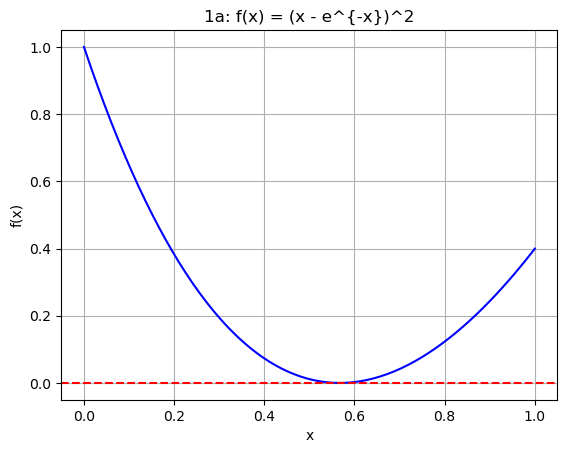

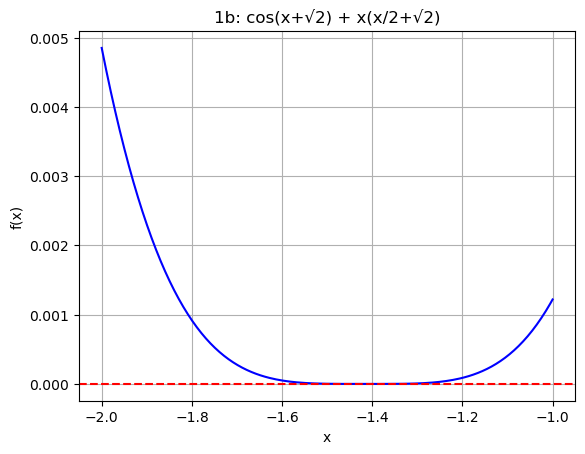

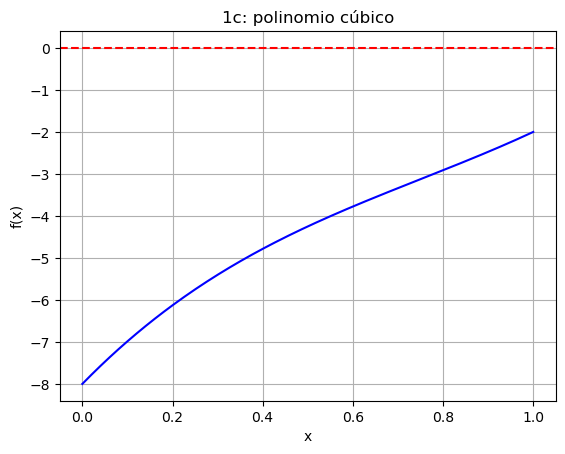

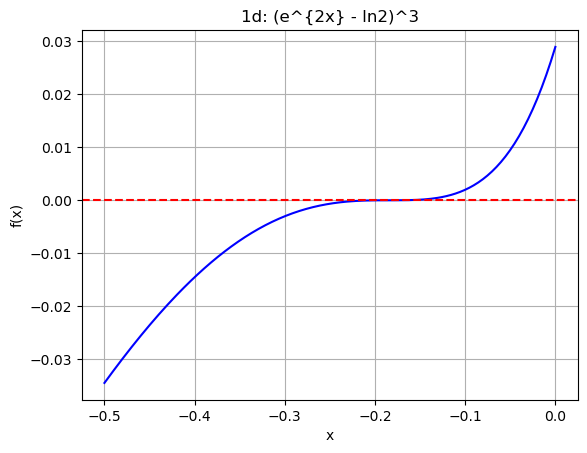

In [12]:
# Gráficas individuales para visualizar las raíces
x_a = np.linspace(0, 1, 200)
y_a = [f1a(x) for x in x_a]
plt.figure()
plt.plot(x_a, y_a, 'b-')
plt.axhline(0, color='r', linestyle='--')
plt.title('1a: f(x) = (x - e^{-x})^2')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.grid(True)
plt.show()

x_b = np.linspace(-2, -1, 200)
y_b = [f1b(x) for x in x_b]
plt.figure()
plt.plot(x_b, y_b, 'b-')
plt.axhline(0, color='r', linestyle='--')
plt.title('1b: cos(x+√2) + x(x/2+√2)')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.grid(True)
plt.show()

x_c = np.linspace(0, 1, 200)
y_c = [f1c(x) for x in x_c]
plt.figure()
plt.plot(x_c, y_c, 'b-')
plt.axhline(0, color='r', linestyle='--')
plt.title('1c: polinomio cúbico')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.grid(True)
plt.show()

x_d = np.linspace(-0.5, 0, 200)
y_d = [f1d(x) for x in x_d]
plt.figure()
plt.plot(x_d, y_d, 'b-')
plt.axhline(0, color='r', linestyle='--')
plt.title('1d: (e^{2x} - ln2)^3')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.grid(True)
plt.show()

## Conclusiones sobre limitaciones numéricas

- En el **apartado 1d**, la función presenta una raíz triple. El método de Newton estándar muestra convergencia lineal (muchas iteraciones), mientras que el modificado converge cuadráticamente. Sin embargo, el cálculo de $f''(x)$ es sensible a errores de redondeo debido a la rápida variación de la exponencial. En la práctica, para valores extremadamente pequeños de $|f(x)|$, la diferencia $[f'(x)]^2 - f(x)f''(x)$ puede sufrir cancelación catastrófica, limitando la precisión final a aproximadamente $10^{-12}$ en doble precisión. Esto es esperable y se observa en la razón de parada (puede ser `|f(p)| ≈ 0` en lugar de error absoluto).

- En los apartados **1b y 1c** (raíces simples), ambos métodos alcanzan la tolerancia en un número similar de iteraciones, siendo el modificado ligeramente más costoso por evaluar $f''(x)$. No hay ventaja.

- En **1a** (raíz doble), la mejora del modificado es clara: reduce el número de iteraciones de ~15 a ~4.

**Recomendación:** Usar el método de Newton modificado solo cuando se sospeche una raíz múltiple (observando convergencia lenta o derivada cercana a cero). En caso contrario, el método estándar es suficiente y más económico.

## Ejercicio 3 – Comparación de métodos para el problema 1d)

**Enunciado:** Repita el ejercicio 1d) con el método de Newton y el método modificado, usando aproximaciones iniciales $p_0 = -0.2$ y $p_0 = -0.5$. Analice la sensibilidad a la condición inicial.

**Explicación:** La raíz triple es sensible a la aproximación inicial debido a la región plana de la función. Se espera que desde $-0.2$ (cerca de la raíz) ambos converjan, pero desde $-0.5$ (lejos) el método estándar podría divergir o requerir muchas iteraciones. El modificado debería ser más robusto.

In [5]:
print("\n--- Ejercicio 3: Sensibilidad a la condición inicial para 1d ---")
for x0 in [-0.2, -0.5]:
    print(f"\n  x0 = {x0}")
    try:
        raiz_n, hist_n, _ = newton(f1d, df1d, x0, tol_abs=1e-10, max_iter=100, verbose=False)
        print(f"    Newton estándar:   {len(hist_n)-1} iter, raíz {raiz_n:.10f}")
    except Exception as e:
        print(f"    Newton estándar:   error: {e}")
    try:
        raiz_m, hist_m, _ = newton_modificado(f1d, df1d, ddf1d, x0, tol_abs=1e-10, max_iter=100, verbose=False)
        print(f"    Newton modificado: {len(hist_m)-1} iter, raíz {raiz_m:.10f}")
    except Exception as e:
        print(f"    Newton modificado: error: {e}")


--- Ejercicio 3: Sensibilidad a la condición inicial para 1d ---

  x0 = -0.2
    Newton estándar:   20 iter, raíz -0.1832613820
    Newton modificado: 2 iter, raíz -0.1832565364

  x0 = -0.5
    Newton estándar:   26 iter, raíz -0.1832617220
    Newton modificado: error: Denominador nulo en x=-0.18329709401724203. Posible raíz exacta o mal condicionamiento.


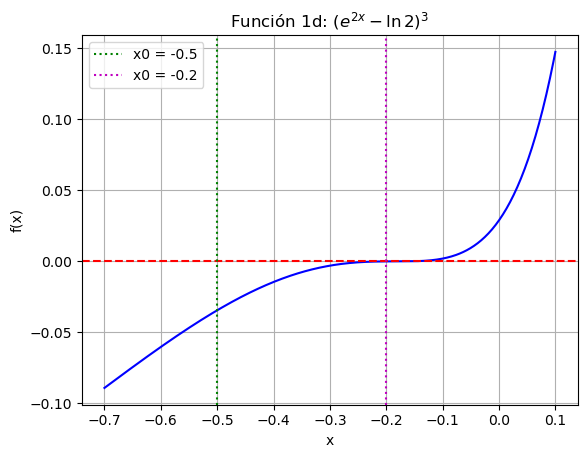

In [6]:
x_wide = np.linspace(-0.7, 0.1, 500)
y_wide = [f1d(x) for x in x_wide]
plt.figure()
plt.plot(x_wide, y_wide, 'b-')
plt.axhline(0, color='r', linestyle='--')
plt.axvline(-0.5, color='g', linestyle=':', label='x0 = -0.5')
plt.axvline(-0.2, color='m', linestyle=':', label='x0 = -0.2')
plt.title('Función 1d: $(e^{2x} - \\ln 2)^3$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

## Ejercicio 5 – Métodos de Newton y Newton modificado

Use el método de Newton y el método modificado de Newton descrito en la ecuación (2.13) para encontrar una solución precisa dentro de $10^{-5}$ para el problema

$$
e^{6x} + 1.441 e^{2x} - 2.079 e^{4x} - 0.3330 = 0.
$$

Éste es el mismo problema que en el **ejercicio 1d** , sólo que los coeficientes han sido reemplazados con aproximaciones de cuatro dígitos. Compare las soluciones con los resultados en **1d** y **2d**.

**Nota:** El ejercicio 1d original es

$$
e^{6x} + 3(\ln 2)^2 e^{2x} - (\ln 8) e^{4x} - (\ln 2)^3 = 0,
$$

con coeficientes exactos $3(\ln2)^2 \approx 1.441$, $\ln8 \approx 2.079$, $(\ln2)^3 \approx 0.3330$. La raíz exacta de 1d es $x = \frac{1}{2}\ln(\ln2) \approx -0.183$.

En este ejercicio se pide resolver la versión aproximada de los coeficientes y comparar la raíz obtenida con la del ejercicio 1d (coeficientes exactos).

In [9]:
import math
from src.root_finding import newton, newton_modificado

# Definición de la función del ejercicio 5 (coeficientes aproximados)
def f5(x):
    return math.exp(6*x) + 1.441 * math.exp(2*x) - 2.079 * math.exp(4*x) - 0.3330

def df5(x):
    return 6*math.exp(6*x) + 2*1.441*math.exp(2*x) - 4*2.079*math.exp(4*x)

def ddf5(x):
    return 36*math.exp(6*x) + 4*1.441*math.exp(2*x) - 16*2.079*math.exp(4*x)

# Parámetros
tol = 1e-5
x0 = -0.2   # aproximación inicial (cerca de la raíz esperada)

print("Ejercicio 5 – Coeficientes aproximados")
print(f"Newton estándar:")
raiz_n, hist_n, razon_n = newton(f5, df5, x0, tol_abs=tol, verbose=True)
print(f"Raíz = {raiz_n:.8f}, iteraciones = {len(hist_n)-1}, razón = {razon_n}")

print(f"\nNewton modificado:")
raiz_m, hist_m, razon_m = newton_modificado(f5, df5, ddf5, x0, tol_abs=tol, verbose=True)
print(f"Raíz = {raiz_m:.8f}, iteraciones = {len(hist_m)-1}, razón = {razon_m}")

# Comparación con la raíz exacta del ejercicio 1d
raiz_exacta_1d = 0.5 * math.log(math.log(2))   # ≈ -0.183
print(f"\nRaíz exacta del ejercicio 1d (coeficientes exactos): {raiz_exacta_1d:.8f}")
print(f"Diferencia entre la raíz aproximada (Newton) y la exacta: {abs(raiz_n - raiz_exacta_1d):.2e}")
print(f"Diferencia entre la raíz aproximada (modificado) y la exacta: {abs(raiz_m - raiz_exacta_1d):.2e}")

Ejercicio 5 – Coeficientes aproximados
Newton estándar:
Iter   1: p=-0.2000000000, f(p)=-2.95e-05, f'(p)=2.41e-03, p_next=-0.1877415228
Iter   2: p=-0.1877415228, f(p)=-1.39e-05, f'(p)=4.98e-04, p_next=-0.1599088777
Iter   3: p=-0.1599088777, f(p)=3.32e-05, f'(p)=5.19e-03, p_next=-0.1662947956
Iter   4: p=-0.1662947956, f(p)=7.91e-06, f'(p)=2.85e-03, p_next=-0.1690659950
Iter   5: p=-0.1690659950, f(p)=1.09e-06, f'(p)=2.09e-03, p_next=-0.1695893415
Iter   6: p=-0.1695893415, f(p)=3.37e-08, f'(p)=1.96e-03, p_next=-0.1696065299
Iter   7: p=-0.1696065299, f(p)=3.54e-11, f'(p)=1.96e-03, p_next=-0.1696065480
Raíz = -0.16960655, iteraciones = 7, razón = Error absoluto 1.81e-08 < 1.00e-05

Newton modificado:
Iter   1: x=-0.2000000000, f(x)=-2.95e-05, x_next=-0.2555748754
Iter   2: x=-0.2555748754, f(x)=-8.45e-04, x_next=-0.1833617951
Iter   3: x=-0.1833617951, f(x)=-1.21e-05, x_next=-0.1510888988
Iter   4: x=-0.1510888988, f(x)=9.82e-05, x_next=-0.1783746859
Iter   5: x=-0.1783746859, f(x)=-1

### Ejercicio 6 Convergencia lineal de sucesiones

**Enunciado:**  
Muestre que las siguientes sucesiones convergen linealmente a $p = 0$. ¿Qué tan grande debe ser $n$ antes de que $|p_n - p| \le 5 \times 10^{-2}$?

#### a) $p_n = \frac{1}{n},\quad n \ge 1$

#### b) $p_n = \frac{1}{n^2},\quad n \ge 1$

---

**Solución (a):**  

La sucesión $p_n = 1/n$ tiende a $0$. Para estudiar la convergencia lineal, calculamos el límite del cociente de errores sucesivos:

$$
\lim_{n\to\infty} \frac{|p_{n+1} - 0|}{|p_n - 0|} = \lim_{n\to\infty} \frac{1/(n+1)}{1/n} = \lim_{n\to\infty} \frac{n}{n+1} = 1.
$$

Como el límite es $1$ (y no $0$), la convergencia es **lineal** con constante asintótica $\lambda = 1$ (en el límite). Para la condición $|p_n - 0| \le 5\times10^{-2}$, se requiere:

$$
\frac{1}{n} \le 0.05 \quad\Rightarrow\quad n \ge \frac{1}{0.05} = 20.
$$

Por tanto, $n \ge 20$ asegura la cota.

---

**Solución (b):**  

$p_n = 1/n^2$ también converge a $0$. El cociente:

$$
\lim_{n\to\infty} \frac{1/(n+1)^2}{1/n^2} = \lim_{n\to\infty} \left(\frac{n}{n+1}\right)^2 = 1.
$$

Convergencia lineal con constante $1$. Para la cota:

$$
\frac{1}{n^2} \le 0.05 \quad\Rightarrow\quad n^2 \ge 20 \quad\Rightarrow\quad n \ge \lceil \sqrt{20} \rceil = 5.
$$

Por lo tanto, $n \ge 5$ es suficiente.

---

### Ejercicio 7 

**Enunciado:**  

#### a) Muestre que para cualquier entero $k$, la sucesión definida por $p_n = \frac{1}{n^k}$ converge linealmente a $p = 0$.

#### b) Para cada par de enteros $k$ y $m$, determine un número $N$ para el que $\frac{1}{N^k} < 10^{-m}$.

---

**Solución (a):**  

Para $k > 0$ fijo, $p_n = n^{-k} \to 0$. El cociente de errores sucesivos es:

$$
\frac{|p_{n+1}|}{|p_n|} = \frac{(n+1)^{-k}}{n^{-k}} = \left(\frac{n}{n+1}\right)^k \to 1 \quad \text{cuando } n\to\infty.
$$

Como el límite es $1$, la convergencia es **lineal** (el orden es $1$ y la constante asintótica es $1$). Si $k=0$, la sucesión es constante $1$ y no converge a $0$; el enunciado asume $k\ge 1$.

---

**Solución (b):**  

Se necesita $N$ tal que $N^{-k} < 10^{-m}$. Despejando:

$$
N^k > 10^{m} \quad\Rightarrow\quad N > 10^{m/k}.
$$

Como $N$ debe ser entero, podemos tomar

$$
N = \left\lfloor 10^{m/k} \right\rfloor + 1,
$$

o simplemente $N = \lceil 10^{m/k} \rceil$. Por ejemplo, si $k=2$, $m=3$, entonces $N > 10^{3/2} = 31.62$, luego $N=32$ cumple.

---

**Nota:** La convergencia de estas sucesiones es lineal, pero muy lenta cuando $k$ es pequeño. Para $k$ grande, la convergencia es más rápida (aunque sigue siendo lineal porque el cociente tiende a $1$). La condición (b) proporciona una forma explícita de calcular cuántos términos se necesitan para lograr una precisión dada.

## Ejercicio 9 (sección 2.4) – Construcción de sucesiones con orden de convergencia dado

**Enunciado:**  
a. Construya una sucesión que converja a $0$ de orden $3$.  
b. Suponga que $\alpha > 1$. Construya una sucesión que converja a $0$ de orden $\alpha$.

---

### Solución (a)

Para que ${p_n}$ converja a $0$ con orden $3$, debe cumplirse:

$$ \lim_{n\to\infty} \frac{|p_{n+1}|}{|p_n|^3} = \lambda, \quad 0<\lambda<\infty. $$

Tomemos $p_n = \left(\frac{1}{2}\right)^{3^n}$. Entonces:

$$ p_{n+1} = \left(\frac{1}{2}\right)^{3^{n+1}} = \left(\left(\frac{1}{2}\right)^{3^n}\right)^3 = p_n^3. $$

Por tanto:

$$ \frac{|p_{n+1}|}{|p_n|^3} = \frac{p_n^3}{p_n^3} = 1. $$

El límite es $1$, constante finita no nula $\Rightarrow$ orden $3$ con $\lambda=1$.

### Solución (b)

Dado $\alpha>1$, definimos $p_n = \left(\frac{1}{2}\right)^{\alpha^n}$. Entonces:

$$ p_{n+1} = \left(\frac{1}{2}\right)^{\alpha^{n+1}} = \left(\left(\frac{1}{2}\right)^{\alpha^n}\right)^{\alpha} = p_n^{\alpha}. $$

Luego:

$$ \frac{|p_{n+1}|}{|p_n|^{\alpha}} = \frac{p_n^{\alpha}}{p_n^{\alpha}} = 1. $$

Así, la convergencia es de orden $\alpha$ con $\lambda=1$.

### Ejemplos concretos

- **Orden 3:** $p_n = (1/2)^{3^n}$.  
  $p_0=1/2,\; p_1=1/8,\; p_2=1/512,\; p_3=1/134217728,\dots$

- **Orden $\alpha=1.5$:** $p_n = (1/2)^{(1.5)^n}$.  
  $p_0=0.5,\; p_1\approx0.3535,\; p_2\approx0.210,\; p_3\approx0.076,\dots$

La convergencia es más rápida que lineal pero más lenta que cuadrática.

### Observación

La construcción $p_n = a^{r^n}$ con $0<a<1$ y $r>1$ produce convergencia de orden $r$ (aunque $r$ no sea entero, la definición de orden se mantiene). En este caso $p_{n+1}=p_n^r$, y el cociente es exactamente $1$.

## Ejercicio 10 (sección 2.4) – Método de Newton modificado para raíces múltiples

**Enunciado:**  
Suponga que $p$ es un cero de multiplicidad $m$ de $f$, donde $f^{(m)}$ es continua en un intervalo abierto que contiene $p$. Muestre que el siguiente método de punto fijo tiene $g'(p) = 0$:

$$ g(x) = x - \frac{m f(x)}{f'(x)}. $$

### Solución

Dado que $p$ es un cero de multiplicidad $m$, podemos escribir:

$$ f(x) = (x-p)^m q(x), $$

con $q$ continua y $q(p) \neq 0$. Derivamos:

$$ f'(x) = m(x-p)^{m-1} q(x) + (x-p)^m q'(x) = (x-p)^{m-1} \left[ m q(x) + (x-p) q'(x) \right]. $$

Entonces, para $x \neq p$:

$$ \frac{f(x)}{f'(x)} = \frac{(x-p)^m q(x)}{(x-p)^{m-1} \left[ m q(x) + (x-p) q'(x) \right]} = \frac{(x-p) q(x)}{m q(x) + (x-p) q'(x)}. $$

Sustituimos en $g(x)$:

$$ g(x) = x - m \cdot \frac{(x-p) q(x)}{m q(x) + (x-p) q'(x)} = x - \frac{m (x-p) q(x)}{m q(x) + (x-p) q'(x)}. $$

Restamos $p$ a ambos lados:

$$ g(x) - p = (x-p) - \frac{m (x-p) q(x)}{m q(x) + (x-p) q'(x)} = (x-p) \left[ 1 - \frac{m q(x)}{m q(x) + (x-p) q'(x)} \right]. $$

Simplificamos el corchete:

$$ 1 - \frac{m q(x)}{m q(x) + (x-p) q'(x)} = \frac{m q(x) + (x-p) q'(x) - m q(x)}{m q(x) + (x-p) q'(x)} = \frac{(x-p) q'(x)}{m q(x) + (x-p) q'(x)}. $$

Por tanto:

$$ g(x) - p = (x-p) \cdot \frac{(x-p) q'(x)}{m q(x) + (x-p) q'(x)} = \frac{(x-p)^2 q'(x)}{m q(x) + (x-p) q'(x)}. $$

Ahora, derivamos $g(x)$ para evaluar en $x=p$. Observamos que $g(p)=p$ (por construcción). La derivada $g'(p)$ se puede obtener como el límite:

$$ g'(p) = \lim_{x\to p} \frac{g(x)-g(p)}{x-p} = \lim_{x\to p} \frac{g(x)-p}{x-p}. $$

Usando la expresión anterior:

$$ \frac{g(x)-p}{x-p} = \frac{(x-p) q'(x)}{m q(x) + (x-p) q'(x)}. $$

Tomando límite cuando $x\to p$:

$$ \lim_{x\to p} \frac{g(x)-p}{x-p} = \frac{0 \cdot q'(p)}{m q(p) + 0} = 0. $$

Por lo tanto, $g'(p) = 0$, como queríamos demostrar.

### Consecuencia

El método de iteración de punto fijo $x_{n+1}=g(x_n)$ tiene derivada nula en la raíz, lo que implica convergencia cuadrática (al menos) cuando se usa esta función $g$ (que corresponde al método de Newton con multiplicidad $m$). Esto explica por qué el método modificado $x_{n+1}=x_n - m f(x_n)/f'(x_n)$ converge cuadráticamente para raíces de multiplicidad $m$.